In [ ]:
import sys
from pathlib import Path

# Project root is one level up from notebooks/
_proj_root = Path.cwd().parent
if str(_proj_root / 'src') not in sys.path:
    sys.path.insert(0, str(_proj_root / 'src'))

DATA_DIR = str(_proj_root / 'data')
print(f'Project root: {_proj_root}')
print(f'src in sys.path: {str(_proj_root / "src") in sys.path}')


In [1]:
import math
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from tabulate import tabulate

from data_loader import load_dataset, print_dataset_summary
from helpers import (
    divide_graph_into_parts,
    calculate_cell_weights,
    plot_cell_weights,
    plot_qubo_diagonal,
    print_weight_summary,
    suggest_parameters,
    print_parameter_suggestions,
)
from qubo_builder import (
    build_qubo,
    evaluate_solution,
    calibrate_alphas,
    print_qubo_diagnostics,
    brute_force_ranking,
)
from qaoa_builder import run_qaoa, run_qaoa_mps, print_qaoa_results
from cell_pruner import (
    prune_cells,
    remap_qubo_for_qaoa,
    translate_results,
    compute_solo_scores,
)
from itertools import combinations

In [2]:
# from pruning_validation import (
#     run_dataset_validation_suite,
#     print_dataset_validation_suite,
#     print_pruning_validation_report,
# )

# cases = [
#     {
#         "label": "Medium City @ N=400",
#         "dataset_file": "dataset_medium_city.xlsx",
#         "N_qubits": 400,
#         "tier3_keep": 3,
#         "tier3_keep_values": [2, 3, 4, 5, 5],
#         "seed": 42,
#     },
#     {
#         "label": "Large City @ N=625",
#         "dataset_file": "dataset_large_city.xlsx",
#         "N_qubits": 625,
#         "tier3_keep": 3,
#         "tier3_keep_values": [2, 3, 4, 5, 7],
#         "seed": 43,
#     },
#     {
#         "label": "Metro Region @ N=900",
#         "dataset_file": "dataset_metro_region.xlsx",
#         "N_qubits": 900,
#         "tier3_keep": 3,
#         "tier3_keep_values": [2, 3, 4, 5, 10],
#         "seed": 44,
#     },
# ]

# suite = run_dataset_validation_suite(
#     cases,
#     random_samples=10_000,
#     ga_generations=500,
#     ga_population=100,
# )

# print_dataset_validation_suite(suite)

# for case in suite:
#     print(f"\n=== {case['label']} ===")
#     print_pruning_validation_report(case["validation"])


In [3]:
# print_dataset_validation_suite(suite)

# for case in suite:
#     print(f"\n=== {case['label']} ===")
#     print_pruning_validation_report(case["validation"])


In [4]:
import os
# ─────────────────────────────────────────────────────────────────────────────
# 1. Load dataset from Excel
# ─────────────────────────────────────────────────────────────────────────────
# Change this path to switch datasets:
#   dataset_small_city.xlsx    — 15 POIs, m=4 (brute-force feasible)
#   dataset_medium_city.xlsx   — 25 POIs, m=5 (pruning + GA territory)
#   dataset_large_city.xlsx    — 40 POIs, m=7 (MPS-QAOA territory)
#   dataset_metro_region.xlsx  — 59 POIs, m=10 (stress test)

DATASET_FILE = os.path.join(DATA_DIR, "dataset_metro_region.xlsx")

data = load_dataset(DATASET_FILE)
print_dataset_summary(data)

# Unpack
points_of_interest       = data['pois']
existing_charging_points = data['existing_chargers']
gas_stations             = data['gas_stations']
M                        = data['m']
X_MIN, X_MAX             = data['x_min'], data['x_max']
Y_MIN, Y_MAX             = data['y_min'], data['y_max']

# Grid and weight parameters
SCALE_FACTOR = 5.0
MIN_WEIGHT   = 0.5
N_QUBITS     = 450  # Change per dataset: 100/196/256/400/625/900

Dataset: metro_region
  59 POIs, full metro with 6 districts + suburban ring, m=10. Stress test.
  Area: [0.0, 40.0] × [0.0, 35.0]
  POIs: 59  |  Chargers: 12  |  Gas: 10  |  m=10
  Density range: [0.19, 0.97]  mean=0.53


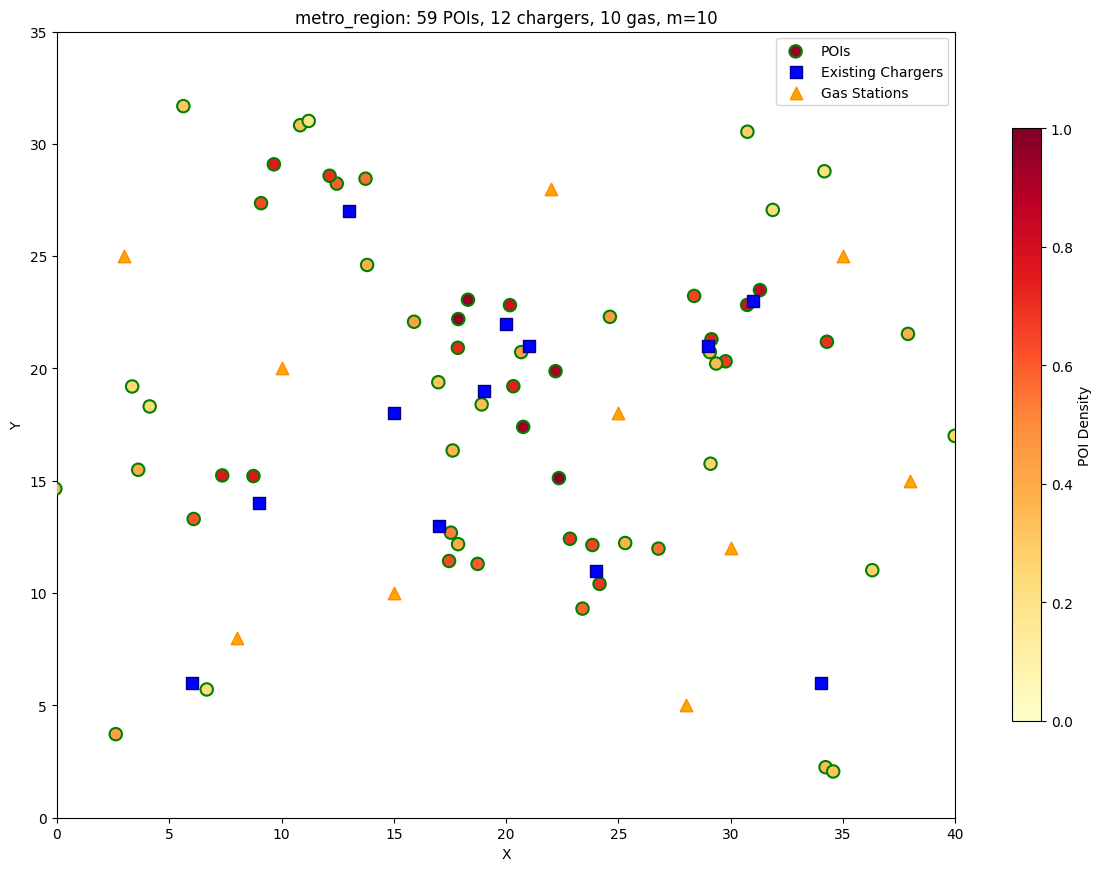

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. Input data visualization
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 9))
sc = ax.scatter(
    [p[0] for p in points_of_interest],
    [p[1] for p in points_of_interest],
    c=[p[2] for p in points_of_interest],
    cmap='YlOrRd', edgecolors='green', linewidths=1.5,
    s=80, vmin=0, vmax=1, zorder=5, label='POIs',
)
plt.colorbar(sc, ax=ax, label='POI Density', shrink=0.7)

if existing_charging_points:
    ax.scatter(*zip(*existing_charging_points), color='blue', marker='s',
               s=80, zorder=5, edgecolors='darkblue', linewidths=1, label='Existing Chargers')
if gas_stations:
    ax.scatter(*zip(*gas_stations), color='orange', marker='^',
               s=80, zorder=5, edgecolors='darkorange', linewidths=1, label='Gas Stations')

ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title(f"{data['dataset_name']}: {len(points_of_interest)} POIs, "
             f"{len(existing_charging_points)} chargers, {len(gas_stations)} gas, m={M}")
ax.legend(loc='upper right')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

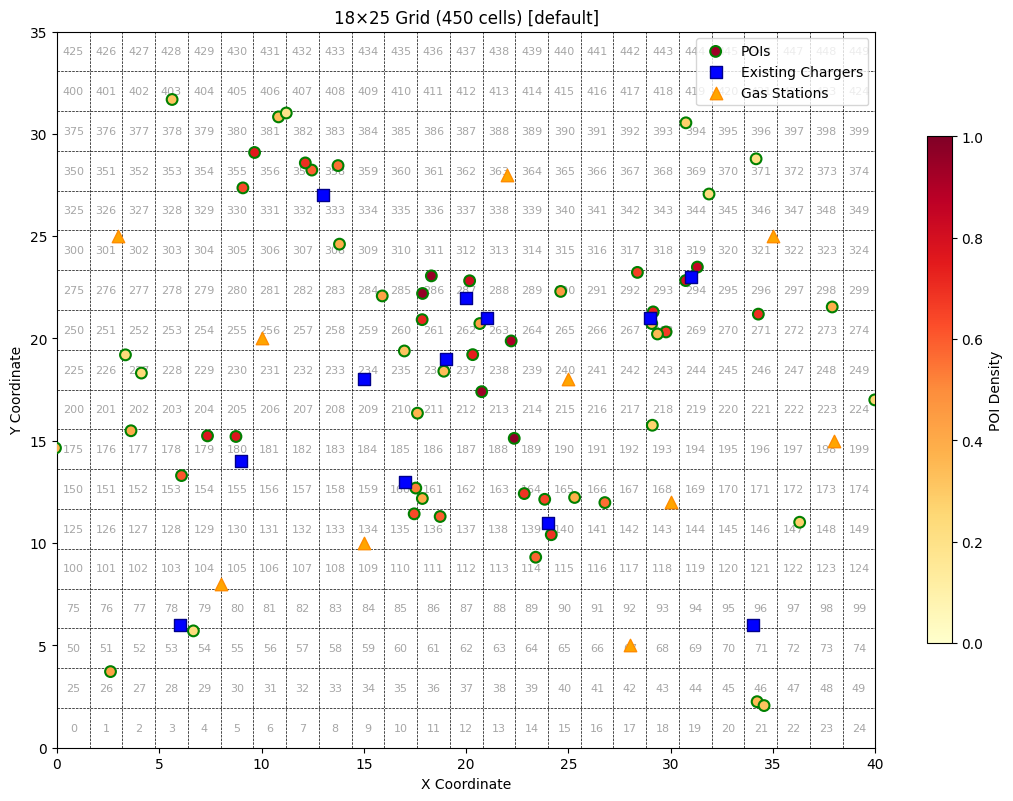

  Grid Info:
    Grid   26 (row=1, col=1): 1 POI(s) [densities: 0.43]
    Grid   46 (row=1, col=21): 2 POI(s) [densities: 0.35, 0.32]
    Grid   54 (row=2, col=4): 1 POI(s) [densities: 0.23]
    Grid   67 (row=2, col=17): 1 gas station(s)
    Grid   78 (row=3, col=3): 1 charger(s)
    Grid   96 (row=3, col=21): 1 charger(s)
    Grid  105 (row=4, col=5): 1 gas station(s)
    Grid  114 (row=4, col=14): 1 POI(s) [densities: 0.58]
    Grid  134 (row=5, col=9): 1 gas station(s)
    Grid  135 (row=5, col=10): 1 POI(s) [densities: 0.64]
    Grid  136 (row=5, col=11): 1 POI(s) [densities: 0.60]
    Grid  140 (row=5, col=15): 1 POI(s) [densities: 0.69] | 1 charger(s)
    Grid  147 (row=5, col=22): 1 POI(s) [densities: 0.28]
    Grid  153 (row=6, col=3): 1 POI(s) [densities: 0.61]
    Grid  160 (row=6, col=10): 1 POI(s) [densities: 0.53] | 1 charger(s)
    Grid  161 (row=6, col=11): 1 POI(s) [densities: 0.40]
    Grid  164 (row=6, col=14): 2 POI(s) [densities: 0.69, 0.65]
    Grid  165 (row=6, c

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. Grid discretization
# ─────────────────────────────────────────────────────────────────────────────

grid_details, plot_deets = divide_graph_into_parts(
    x_min=X_MIN, x_max=X_MAX, y_min=Y_MIN, y_max=Y_MAX,
    num_qubits=N_QUBITS,
    points_of_interest=points_of_interest,
    existing_chargers=existing_charging_points,
    gas_stations=gas_stations,
    grid_division="default",
)

CELL WEIGHT SUMMARY
------------------------  ----------
Total cells               450
Cells with POIs           51 (11.3%)
Total aggregated density  31.34
Max weight                5.00
Min non-zero weight       0.50
Total gas stations        10
Total existing chargers   12
------------------------  ----------

TOP 15 CELLS BY WEIGHT (Grid Data Table):
  Grid ID    Row    Col    # POIs    Raw    Norm    Weight    Gas Sta.    Chargers
---------  -----  -----  --------  -----  ------  --------  ----------  ----------
      268     10     18         4   2.11   1         5               0           1
      286     11     11         2   1.91   0.905     4.526           0           0
      164      6     14         2   1.34   0.635     3.175           0           0
      357     14      7         2   1.29   0.611     3.057           0           0
      188      7     13         1   0.97   0.46      2.299           0           0
      212      8     12         1   0.94   0.445     2.227     

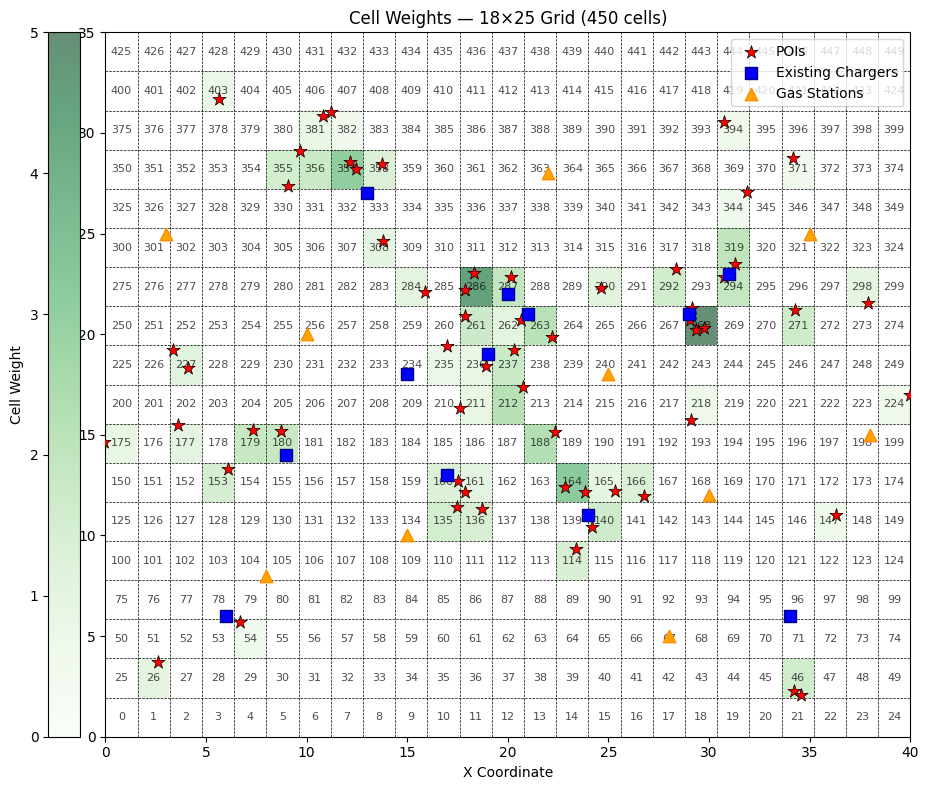

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. Cell weight calculation
# ─────────────────────────────────────────────────────────────────────────────

cell_weights = calculate_cell_weights(
    grid_details, scale_factor=SCALE_FACTOR, min_weight=MIN_WEIGHT
)
print_weight_summary(cell_weights, grid_details, top_n=15)

plot_cell_weights(
    plot_deets, grid_details, cell_weights,
    points_of_interest=points_of_interest,
    existing_chargers=existing_charging_points,
    gas_stations=gas_stations,
    show_data_points=True, show_weight_values=True,
    cell_cmap='Greens', poi_style='solid_red',
)

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. Parameter suggestion (FA-002)
# ─────────────────────────────────────────────────────────────────────────────

params = suggest_parameters(grid_details, cell_weights, plot_deets, m=M)
print_parameter_suggestions(params)

a = params['alpha']
r = params['radii']
t = params['intra']
lambda_val = params['lambda']

SUGGESTED PARAMETERS

Local Radii:
Radius                                      Value
----------------------------------------  -------
R₁  — H1 POI attraction radius                  6
Rₛ  — service gap radius (matches R₁)           6
R₃  — H3 existing charger penalty radius        3
R₄  — H4 new charger spacing radius             4
R₆  — H6 coverage redundancy radius             3

Objective Weights (α):
Parameter                                     Value
------------------------------------------  -------
α₁  — H1 POI attraction         [dominant]     3
α₂  — H2 gas station bonus                     0.5
α₃  — H3 existing charger penalty              0.92
α₄  — H4 new charger spacing                   0.5
α₅  — H5 constraint  (applied to λ)            1
α₆  — H6 coverage redundancy                   0.2

Intra-term Magnitudes:
Parameter                                  Value
---------------------------------------  -------
β  — gas station bonus magnitude               1
γ  — existing

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. QUBO construction
# ─────────────────────────────────────────────────────────────────────────────

Q_obj, h5_params, diags = build_qubo(
    grid_details, cell_weights, plot_deets, m=M,
    alpha1=a['a1'], alpha2=a['a2'], alpha3=a['a3'],
    alpha4=a['a4'], alpha5=a['a5'], alpha6=a['a6'],
    beta=t['beta'], gamma=t['gamma'], delta=t['delta'], epsilon=t['epsilon'],
    lam=lambda_val,
    R1=r['R1'], Rs=r['Rs'], R3=r['R3'], R4=r['R4'], R6=r['R6'],
)

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 7. Post-build calibration
# ─────────────────────────────────────────────────────────────────────────────

params_flat = {
    'alpha1': a['a1'], 'alpha2': a['a2'], 'alpha3': a['a3'],
    'alpha4': a['a4'], 'alpha5': a['a5'], 'alpha6': a['a6'],
    'beta': t['beta'], 'gamma': t['gamma'], 'delta': t['delta'], 'epsilon': t['epsilon'],
    'lam': lambda_val,
    'R1': r['R1'], 'Rs': r['Rs'], 'R3': r['R3'], 'R4': r['R4'], 'R6': r['R6'],
}

params_flat, needs_rebuild = calibrate_alphas(Q_obj, params_flat, diags, verbose=True)
if needs_rebuild:
    print("\nRebuilding Q_obj with calibrated parameters...")
    Q_obj, h5_params, diags = build_qubo(
        grid_details, cell_weights, plot_deets, m=M, **params_flat,
    )
    print("Rebuild complete.")

print_qubo_diagnostics(diags, params=params_flat)

CALIBRATE_ALPHAS
  Diagonal peak:  2.8783
  Target (×0.5): 1.4391
  H4 actual peak: 0.2500  ✓ OK
  H6 actual peak: 1.0169  ✓ OK
  → No rebuild needed.
QUBO CONSTRUCTION DIAGNOSTICS (Q_obj — H1 through H6, H5 separate)

Grid:  N=450 cells,  m=10 new chargers
  POI cells:            51
  Cells w/ chargers:    12
  Individual chargers:  12  (E_all — counts: {96: 1, 160: 1, 294: 1, 263: 1, 234: 1, 140: 1, 236: 1, 78: 1, 268: 1, 333: 1, 180: 1, 287: 1})
  Radii: R1=6, Rs=6, R3=3, R4=4, R6=3

Call parameters:
  alpha1       = 3.0
  alpha2       = 0.5
  alpha3       = 0.92
  alpha4       = 0.5
  alpha5       = 1.0
  alpha6       = 0.2
  beta         = 1.0
  gamma        = 1.0
  delta        = 1.0
  epsilon      = 1.0
  lam          = 175.0
  R1           = 6
  Rs           = 6
  R3           = 3
  R4           = 4
  R6           = 3

NORMALIZATION SCALES (raw max-abs, divisor applied before α):
  H1 : scale=5.04803  raw range [-5.0480, -0.3362]
  H2 : scale=1.00000  raw range [-1.0000, -0.000

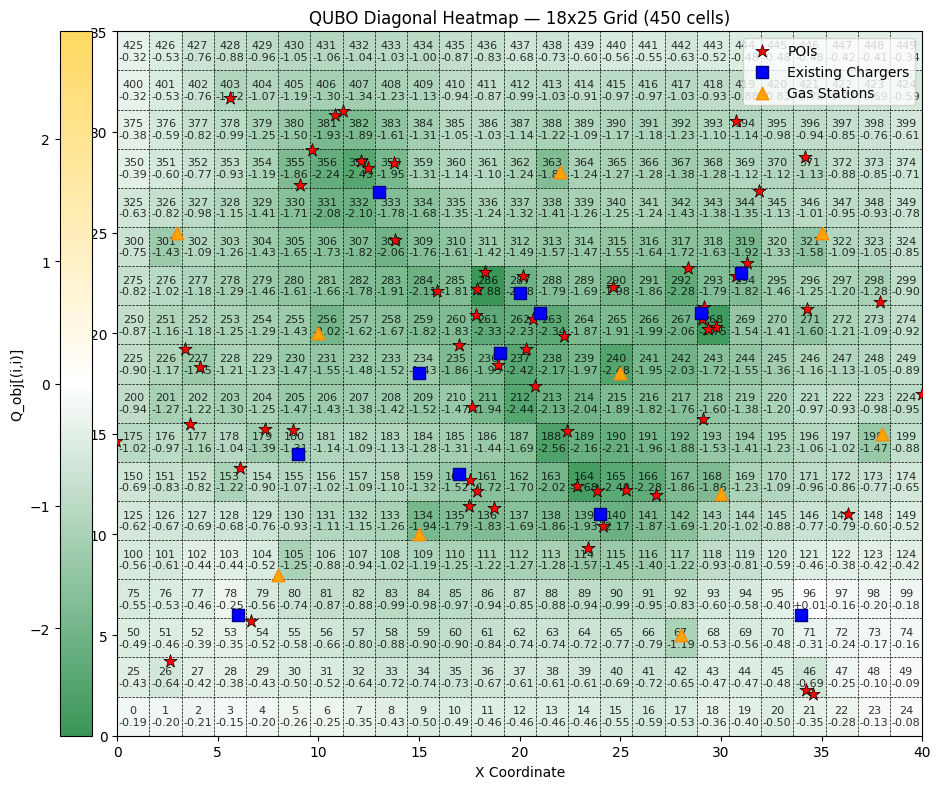

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 8. QUBO diagonal heatmap (cell-wise Q_obj[(i,i)] values)
# ─────────────────────────────────────────────────────────────────────────────

plot_qubo_diagonal(
    plot_deets, grid_details, Q_obj,
    points_of_interest=points_of_interest,
    existing_chargers=existing_charging_points,
    gas_stations=gas_stations,
    show_data_points=True,
    show_qubo_values=True,
    show_grid_ids=True,
    poi_style='solid_red',
)


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# 8. Brute force on full Q (only if feasible — skip for large grids)
# ─────────────────────────────────────────────────────────────────────────────

n_combos = math.comb(N_QUBITS, M)
print(f"C({N_QUBITS},{M}) = {n_combos:,}")

if n_combos <= 500_000:
    top_solutions = brute_force_ranking(Q_obj, N=N_QUBITS, m=M, top_k=10)
    print(f"\nTOP 10 solutions (full Q):")
    for rank, (score, sol) in enumerate(top_solutions, 1):
        print(f"  {rank:>2}. score={score:>8.4f}  cells={list(sol)}")
    full_optimal_score = top_solutions[0][0]
    full_optimal_cells = set(top_solutions[0][1])
else:
    print(f"Too large for brute force — skipping.")
    top_solutions = None
    full_optimal_score = None
    full_optimal_cells = None

C(450,10) = 84,844,517,431,032,875,880
Too large for brute force — skipping.


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# 9. Cell Pruning
# ─────────────────────────────────────────────────────────────────────────────

surviving_cells, prune_report = prune_cells(
    Q_obj, N=N_QUBITS, m=M,
    num_cols=plot_deets['num_cols'],
    R4=r['R4'],
    tier3_keep=3,
    verbose=True,
)

# Validate against brute force if available
if full_optimal_cells is not None:
    preserved = full_optimal_cells.issubset(set(surviving_cells))
    print(f"\nFull-Q optimal {sorted(full_optimal_cells)} preserved? "
          f"{'YES' if preserved else 'NO'}")

CELL PRUNING
  Starting cells: 450
  Solo scores: 449 negative, 0 zero, 1 positive
  Solo range: [-2.8783, 0.0082]

  Tier 1 (dead cells): 0 pruned, 450 remain  (0 zero-solo cells kept near competitive)
  Tier 2 (bound elim): 0 pruned, 450 remain  (ref score=-20.4177)
  Tier 3 (dedup):      216 pruned, 234 remain  (69 clusters, sizes=[7, 8, 86, 14, 1, 1, 1, 1, 1, 1, 1, 9, 1, 2, 78, 1, 9, 1, 6, 3, 1, 26, 1, 4, 3, 2, 54, 1, 1, 12, 1, 1, 9, 1, 3, 1, 1, 1, 1, 1, 1, 6, 1, 4, 1, 1, 1, 1, 4, 1, 9, 1, 1, 1, 1, 5, 16, 10, 4, 4, 1, 1, 1, 1, 1, 2, 2, 4, 7])

  RESULT: 450 → 234 cells (48% reduction)
  Surviving IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 21, 22, 26, 46, 47, 67, 71, 72, 73, 74, 78, 80, 83, 84, 85, 86, 89, 90, 91, 96, 97, 98, 99, 105, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 118, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 142, 146, 147, 148, 149, 151, 152, 155, 156, 157, 158, 159, 161, 162, 163, 164, 165, 166, 172, 173, 174, 175, 176, 178, 181, 182,

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# 10. Remap QUBO to pruned variable space
# ─────────────────────────────────────────────────────────────────────────────

Q_pruned, cell_to_qubit, qubit_to_cell = remap_qubo_for_qaoa(Q_obj, surviving_cells)
K = len(surviving_cells)

print(f"Remapped: {N_QUBITS} → {K} qubits ({100*(1-K/N_QUBITS):.0f}% reduction)")
print(f"  Q_pruned entries: {len(Q_pruned)}")
print(f"  Search space: C({K},{M}) = {math.comb(K, M):,} "
      f"(was C({N_QUBITS},{M}) = {math.comb(N_QUBITS, M):,})")

h5_params_pruned = {'lam': h5_params['lam'], 'alpha5': h5_params['alpha5'], 'm': M}

Remapped: 450 → 234 qubits (48% reduction)
  Q_pruned entries: 6351
  Search space: C(234,10) = 111,615,289,529,457,285 (was C(450,10) = 84,844,517,431,032,875,880)


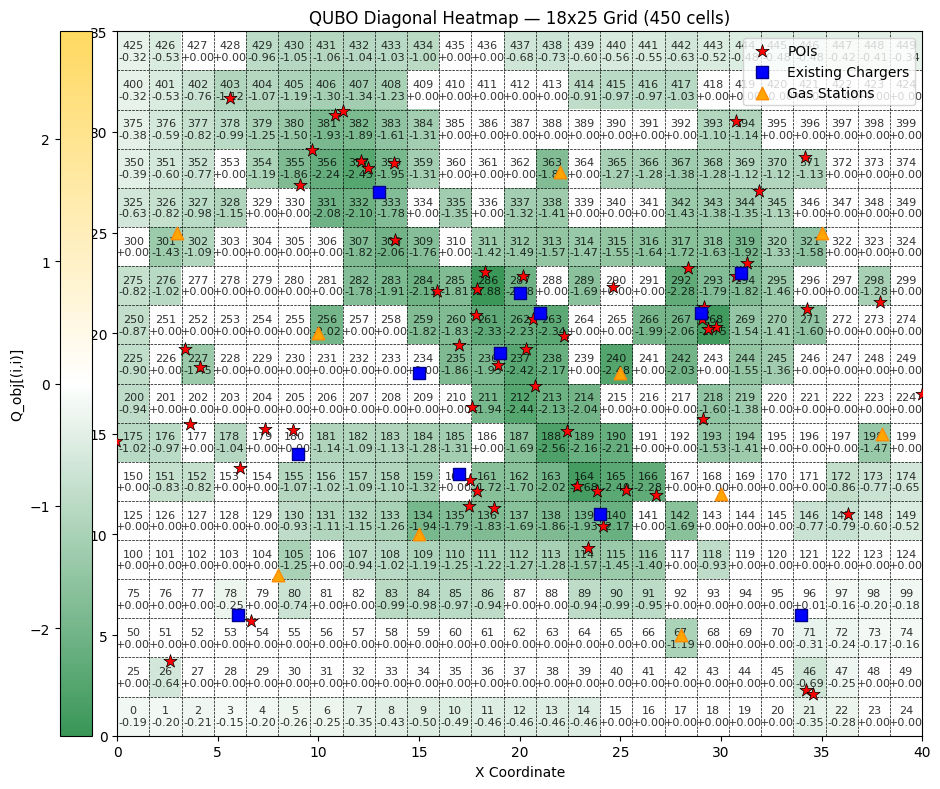

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# 8. QUBO diagonal heatmap (cell-wise Q_obj[(i,i)] values)
# ─────────────────────────────────────────────────────────────────────────────

# Q_pruned is indexed by remapped qubit IDs 0..K-1.
# Convert it back to original grid IDs before plotting so the cell numbers
# match the grid and the pruning visualization below.
Q_pruned_on_original_grid = {
    (qubit_to_cell[i], qubit_to_cell[i]): val
    for (i, j), val in Q_pruned.items()
    if i == j
}

plot_qubo_diagonal(
    plot_deets, grid_details, Q_pruned_on_original_grid,
    points_of_interest=points_of_interest,
    existing_chargers=existing_charging_points,
    gas_stations=gas_stations,
    
    show_data_points=True,
    show_qubo_values=True,
    show_grid_ids=True,
    poi_style='solid_red',
)


In [12]:
from pruning_validation import run_pruning_validation, print_pruning_validation_report

validation = run_pruning_validation(
    Q_obj=Q_obj,
    N=N_QUBITS,
    m=M,
    num_cols=plot_deets["num_cols"],
    R4=r["R4"],
    surviving_cells=surviving_cells,
    tier3_keep_values=[2, 3, 4, 5, M],
    random_samples=10_000,
    ga_generations=500,
    ga_population=100,
    seed=42,
)

print_pruning_validation_report(validation)
validation


TIER-3 SCALE VALIDATION
N=256  K=90  reduction=64.8%  m=5
Check 1 - Greedy comparison: PASS
  full=-12.1387  pruned=-12.1387  gap=0.00%  same_cells=True
Check 2 - Random sampling: PASS
  best full/pruned=-9.7189/-11.8841  mean full/pruned=-4.9795/-6.9099  p5 full/pruned=-7.1321/-8.6637
Check 3 - GA convergence: PASS
  best full/pruned=-12.2466/-12.2466  95% gen full/pruned=47/35
Check 4 - Neighbor coverage: PASS
  Every full-greedy cell kept at least one surviving d<=2 alternative.
Check 5 - Sensitivity sweep: PASS
  knee_keep=2
  keep= 2 -> K=  67  greedy=-12.1387  gap_vs_full=0.00%
  keep= 3 -> K=  77  greedy=-12.1387  gap_vs_full=0.00%
  keep= 4 -> K=  84  greedy=-12.1387  gap_vs_full=0.00%
  keep= 5 -> K=  90  greedy=-12.1387  gap_vs_full=0.00%


{'summary': {'original_N': 256,
  'surviving_K': 90,
  'reduction_pct': 64.84375,
  'm': 5},
 'check_1_greedy_comparison': {'status': 'PASS',
  'full_greedy_cells': [120, 131, 139, 181, 187],
  'full_greedy_score': -12.138708625551798,
  'pruned_greedy_cells': [120, 131, 139, 181, 187],
  'pruned_greedy_score': -12.138708625551798,
  'same_cells': True,
  'score_gap_pct': 0.0,
  'threshold_pct': 5.0},
 'check_2_random_sampling': {'status': 'PASS',
  'samples_per_space': 10000,
  'full': {'best': -9.718910581206586,
   'mean': -4.979511702788087,
   'p5': -7.132071363433833},
  'pruned': {'best': -11.884114296057493,
   'mean': -6.909938418915856,
   'p5': -8.663691144701557},
  'best_gap_pct': 22.278255332832796,
  'mean_pass': True,
  'p5_pass': True,
  'best_pass': True,
  'best_full_solution': [70, 90, 114, 139, 181],
  'best_pruned_solution': [88, 131, 139, 181, 187]},
 'check_3_ga_convergence': {'status': 'PASS',
  'full': {'best_score': -12.246632480117151,
   'best_solution': [1

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# 11. QAOA — Statevector on pruned Q
# ─────────────────────────────────────────────────────────────────────────────
# Only feasible if K <= ~25 (2^K must fit in RAM).
# For larger K, skip this cell and use GA or MPS-QAOA instead.


if K <= 25:
    qaoa_results_pruned, qaoa_params = run_qaoa(
        Q_pruned,
        h5_params_pruned,
        N=K,
        m=M,
        p=3,
        max_iter=300,
        n_restarts=3,
        seed=42,
        verbose=True,
    )
    qaoa_mode = "statevector"

elif K <= 120:
    qaoa_results_pruned, qaoa_params = run_qaoa_mps(
        Q_pruned,
        h5_params_pruned,
        N=K,
        m=M,
        p=1,
        max_iter=100,          # slightly lower to keep runtime sane
        shots=5000,
        n_restarts=1,
        seed=42,
        verbose=True,
        max_bond_dimension=32,     # start conservative; tune later
        truncation_threshold=1e-10,
    )
    qaoa_mode = "mps"

else:
    print(f"K={K} too large even for a practical first MPS-QAOA run.")
    print("Use GA, or reduce p / bond dimension / problem size further.")
    qaoa_results_pruned = None
    qaoa_params = None
    qaoa_mode = None

if qaoa_results_pruned is not None:
    qaoa_results_cells = translate_results(qaoa_results_pruned, qubit_to_cell)

    num_cols = plot_deets['num_cols']
    prob_label = "Prob" if qaoa_mode == "statevector" else "EmpProb"

    print(f"\nQAOA mode used: {qaoa_mode}")
    print(f"\n{'Rank':<6} {'Score':>10} {prob_label:>10}   {'Cell IDs':<30} {'Positions (r,c)'}")
    print("─" * 90)

    for rank, (score, cells_list, prob) in enumerate(qaoa_results_cells, 1):
        positions = [(cell_id // num_cols, cell_id % num_cols) for cell_id in cells_list]
        print(f"  {rank:<4} {score:>10.4f} {prob:>10.6f}   {str(cells_list):<30} {positions}")
else:
    qaoa_results_cells = None

QAOA MPS Pipeline: N=90, m=5, p=1, restarts=1, max_iter=100, shots=5000, top_k=8
  AerSimulator: method=matrix_product_state, bond_dim=32, trunc=1e-10, measure_algo=mps_apply_measure, threads=12


CircuitTooWideForTarget: 'Number of qubits (90) in circuit-4247 is greater than maximum (63) in the coupling_map'

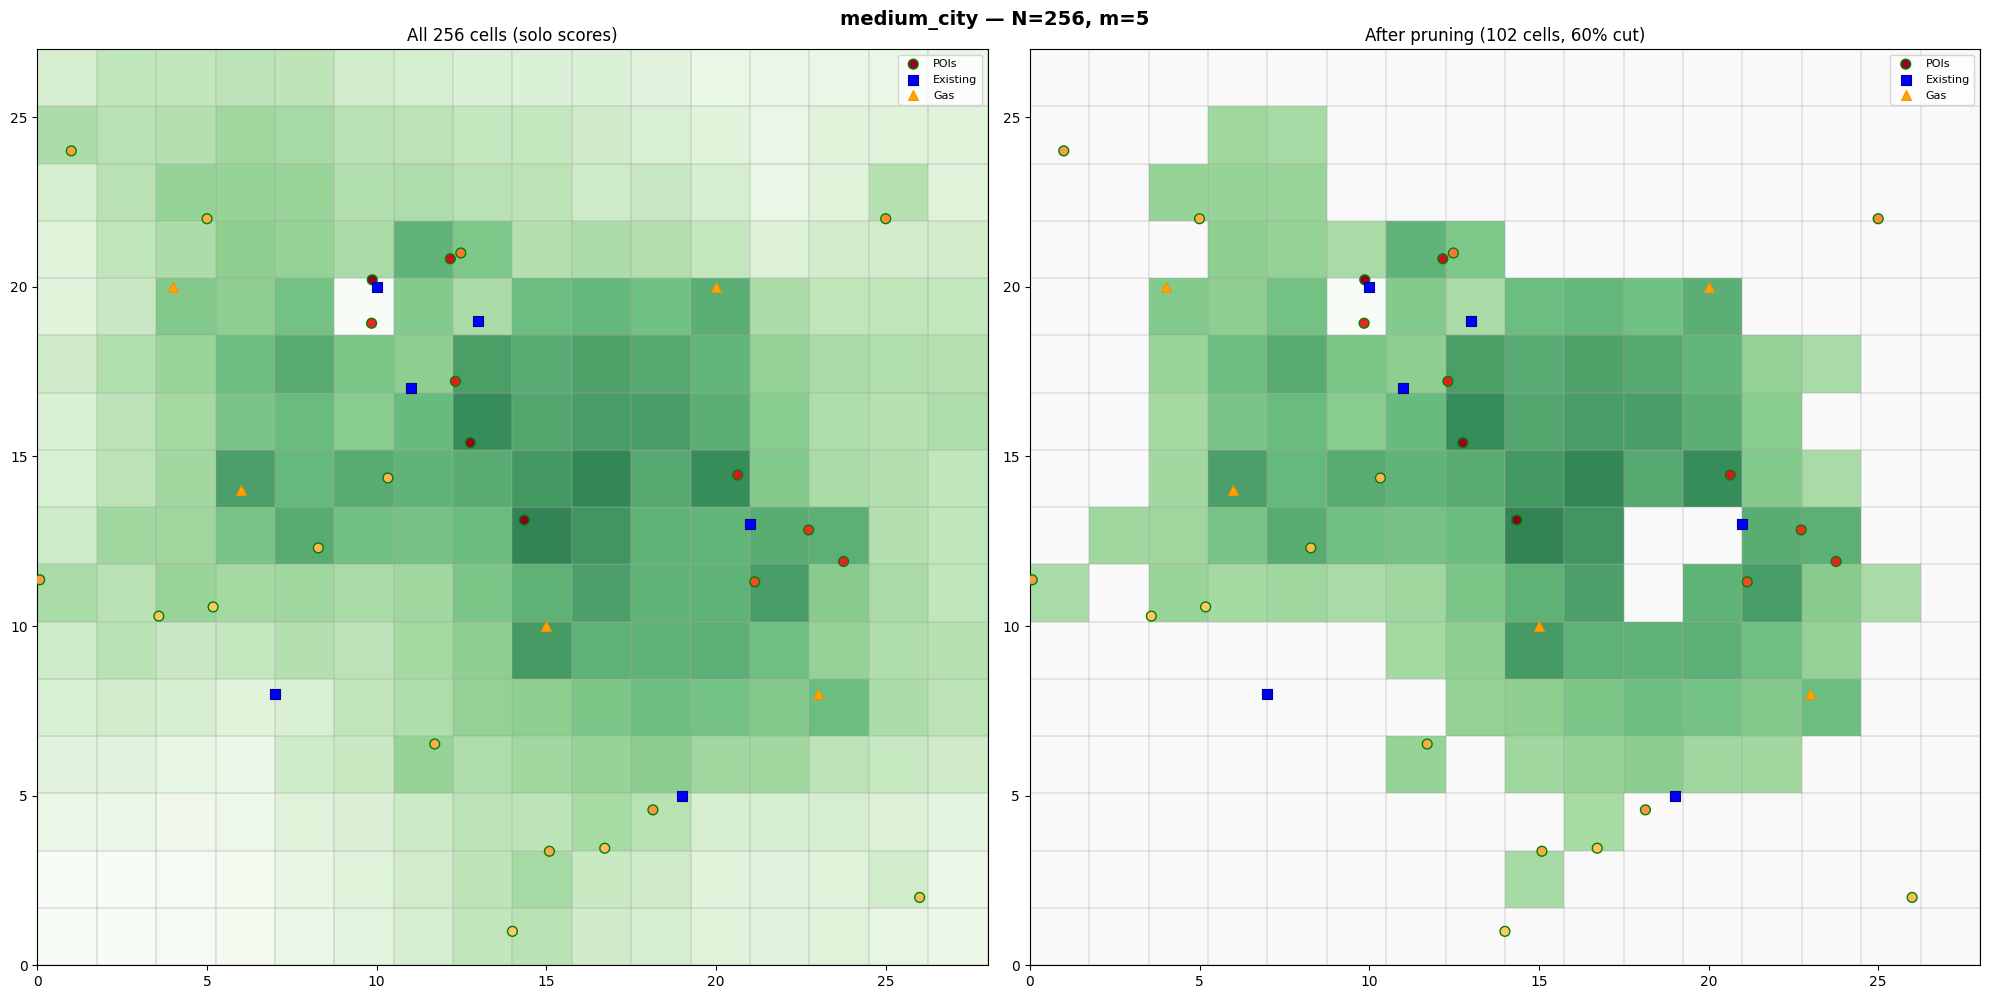

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# 12. Pruning visualization
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
solos = compute_solo_scores(Q_obj, N_QUBITS)
num_rows = plot_deets['num_rows']
num_cols = plot_deets['num_cols']
cell_w = plot_deets['cell_w']
cell_h = plot_deets['cell_h']

for ax_idx, (ax, title, highlight) in enumerate(zip(
    axes,
    [f'All {N_QUBITS} cells (solo scores)',
     f'After pruning ({K} cells, {100*(1-K/N_QUBITS):.0f}% cut)'],
    [set(range(N_QUBITS)), set(surviving_cells)],
)):
    ax.set_facecolor('white')
    for i in range(num_cols + 1):
        ax.axvline(x=X_MIN + i * cell_w, color='gray', linestyle='-', linewidth=0.2)
    for j in range(num_rows + 1):
        ax.axhline(y=Y_MIN + j * cell_h, color='gray', linestyle='-', linewidth=0.2)

    for gid, info in grid_details.items():
        if gid in highlight:
            score = solos[gid]
            norm = max(0, min(1, -score / 3.0))
            color = plt.cm.Greens(norm)
            alpha = 0.8
        else:
            color = (0.93, 0.93, 0.93)
            alpha = 0.3
        ax.add_patch(plt.Rectangle(
            (info['x_start'], info['y_start']), cell_w, cell_h,
            facecolor=color, alpha=alpha, edgecolor='lightgray', linewidth=0.2,
        ))

    if points_of_interest:
        ax.scatter([p[0] for p in points_of_interest],
                   [p[1] for p in points_of_interest],
                   c=[p[2] for p in points_of_interest], cmap='YlOrRd',
                   edgecolors='green', linewidths=1, s=50, vmin=0, vmax=1,
                   zorder=5, label='POIs')
    if existing_charging_points:
        ax.scatter(*zip(*existing_charging_points), color='blue', marker='s',
                   s=50, zorder=5, edgecolors='darkblue', linewidths=0.8, label='Existing')
    if gas_stations:
        ax.scatter(*zip(*gas_stations), color='orange', marker='^',
                   s=50, zorder=5, edgecolors='darkorange', linewidths=0.8, label='Gas')

    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_aspect('equal')

plt.suptitle(f"{data['dataset_name']} — N={N_QUBITS}, m={M}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 13. Summary
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 70)
print("PIPELINE SUMMARY")
print("=" * 70)
print(f"  Dataset:    {data['dataset_name']}")
print(f"  Grid:       {N_QUBITS} cells ({plot_deets['num_rows']}×{plot_deets['num_cols']})")
print(f"  POIs:       {len(points_of_interest)}")
print(f"  Chargers:   {len(existing_charging_points)} existing, {M} new to place")
print(f"  Gas:        {len(gas_stations)}")
print(f"  Pruning:    {N_QUBITS} → {K} ({100*(1-K/N_QUBITS):.0f}% reduction)")
print(f"    Tier 1:   {prune_report['tier1']['pruned']} pruned")
print(f"    Tier 2:   {prune_report['tier2']['pruned']} pruned")
print(f"    Tier 3:   {prune_report['tier3']['pruned']} pruned")
print(f"  Search:     C({N_QUBITS},{M})={math.comb(N_QUBITS,M):,} → "
      f"C({K},{M})={math.comb(K,M):,}")

if full_optimal_score is not None:
    print(f"  BF optimal: {full_optimal_score:.4f} cells={sorted(full_optimal_cells)}")
if qaoa_results_cells:
    print(f"  QAOA best:  {qaoa_results_cells[0][0]:.4f} cells={qaoa_results_cells[0][1]}")
print("=" * 70)